# Doublet Detection

In [1]:
# Load packages
suppressPackageStartupMessages({
    library(irlba)
    library(Rtsne)
    library(ggplot2)
    library(biomaRt)
    library(BiocParallel)
    library(Matrix)
    library(matrixStats)
    library(igraph)
    library(scater)
    library(reshape2)
    library(knitr)
    library(scran)
    library(reticulate)
    library(batchelor)
    library(gridExtra)
})
    ncores = 4
    mcparam = MulticoreParam(workers = ncores)
    register(mcparam)

options(repr.plot.width=15, repr.plot.height=8)

In [5]:
main = "/rds/project/rds-SDzz0CATGms/users/bt392/01_Eomes_RNA/"
dir.create(paste0(main, '05_doublet_detection/'), showWarnings = FALSE)

source(paste0(main, "mapping_functions.R"))
load_data()
meta$index = 1:nrow(meta)
meta$sample = meta$batch

In [6]:
head(meta,2)
sce

,cell,barcode,stage,batch,Sample_name,batch_name,tdTom,index,sample
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<int>
1,cell_1,AAACCCAGTTCTCTAT,E8.5,3,MLT_G9 Tom+,SLX-20795_SITTA11_HKTG2DRXY,positive,1,3
2,cell_2,AAACGCTAGTGATTCC,E8.5,3,MLT_G9 Tom+,SLX-20795_SITTA11_HKTG2DRXY,positive,2,3


class: SingleCellExperiment 
dim: 29453 30171 
metadata(0):
assays(2): counts logcounts
rownames(29453): ENSMUSG00000051951 ENSMUSG00000089699 ...
  ENSMUSG00000095742 tomato-td
rowData names(0):
colnames(30171): cell_1 cell_2 ... cell_30170 cell_30171
colData names(1): sizeFactor
reducedDimNames(0):
altExpNames(0):

In [7]:
# Running UMAP from python
source_python(paste0(main, 'UMAP_R_to_py.py'))
run_umap = function(pca_in){
    umap = as.data.frame(umap_redu(pca_in))
    colnames(umap) = c('umap_1', 'umap_2')
    rownames(umap) = meta$cell
    return(umap)    
}

In [8]:
sub_sces = lapply(unique(meta$sample), function(x) return(scater::logNormCounts(sce[, meta$sample == x])))
                  
hvg.list = lapply(sub_sces, getHVGs, block=NULL)
names(hvg.list) = unique(meta$sample)
set.seed(42)
scores_hvgs = lapply(1:length(sub_sces), function(i) doubletCells(sub_sces[[i]],
                                                                  subset.row = rownames(sub_sces[[i]]) %in% hvg.list[[i]]))
scores_hvgs = do.call(c, scores_hvgs)

scores = scores_hvgs
                     
## doubletCells deprecated so possibly won't work much longer

Warning message:
“'doubletCells' is deprecated.
Use 'scDblFinder::computeDoubletDensity' instead.
See help("Deprecated")”
Warning message:
“'doubletCells' is deprecated.
Use 'scDblFinder::computeDoubletDensity' instead.
See help("Deprecated")”
Warning message:
“'doubletCells' is deprecated.
Use 'scDblFinder::computeDoubletDensity' instead.
See help("Deprecated")”
Warning message:
“'doubletCells' is deprecated.
Use 'scDblFinder::computeDoubletDensity' instead.
See help("Deprecated")”
Warning message:
“'doubletCells' is deprecated.
Use 'scDblFinder::computeDoubletDensity' instead.
See help("Deprecated")”
Warning message:
“'doubletCells' is deprecated.
Use 'scDblFinder::computeDoubletDensity' instead.
See help("Deprecated")”
Warning message:
“'doubletCells' is deprecated.
Use 'scDblFinder::computeDoubletDensity' instead.
See help("Deprecated")”
Warning message:
“'doubletCells' is deprecated.
Use 'scDblFinder::computeDoubletDensity' instead.
See help("Deprecated")”


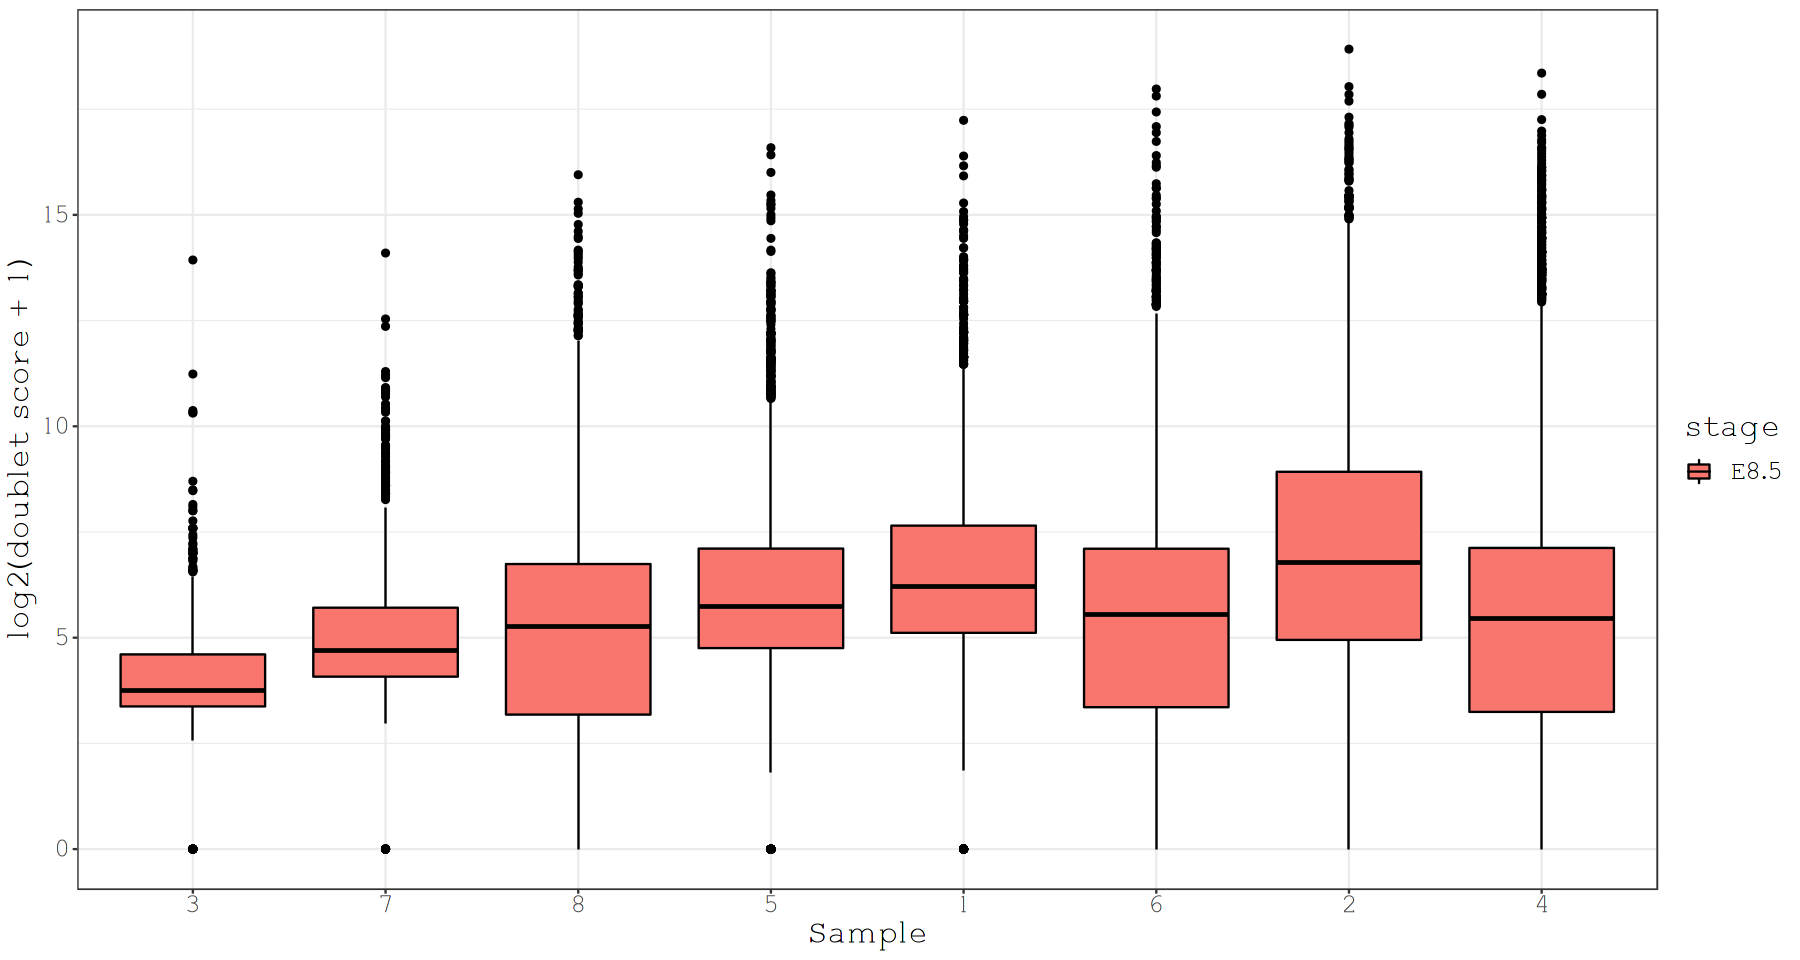

In [9]:
sampsize = melt(table(meta$sample))
order = order(sampsize$value, decreasing = FALSE)


ggplot(data.frame(score = log2(scores+1), sample = meta$sample, stage = meta$stage), aes (x = factor(sample, levels = sampsize$Var1[order]), y = score, fill = stage)) +
  geom_boxplot(col = "black") +
  theme_bw() +
  theme(text= element_text(size=20)) +
  labs(y = "log2(doublet score + 1)", x = "Sample")
  # labs(y = "log2(doublet score + 1)", x = "Sample") +
  # scale_fill_manual(values = stage_colours, labels = stage_labels, name = "Stage")

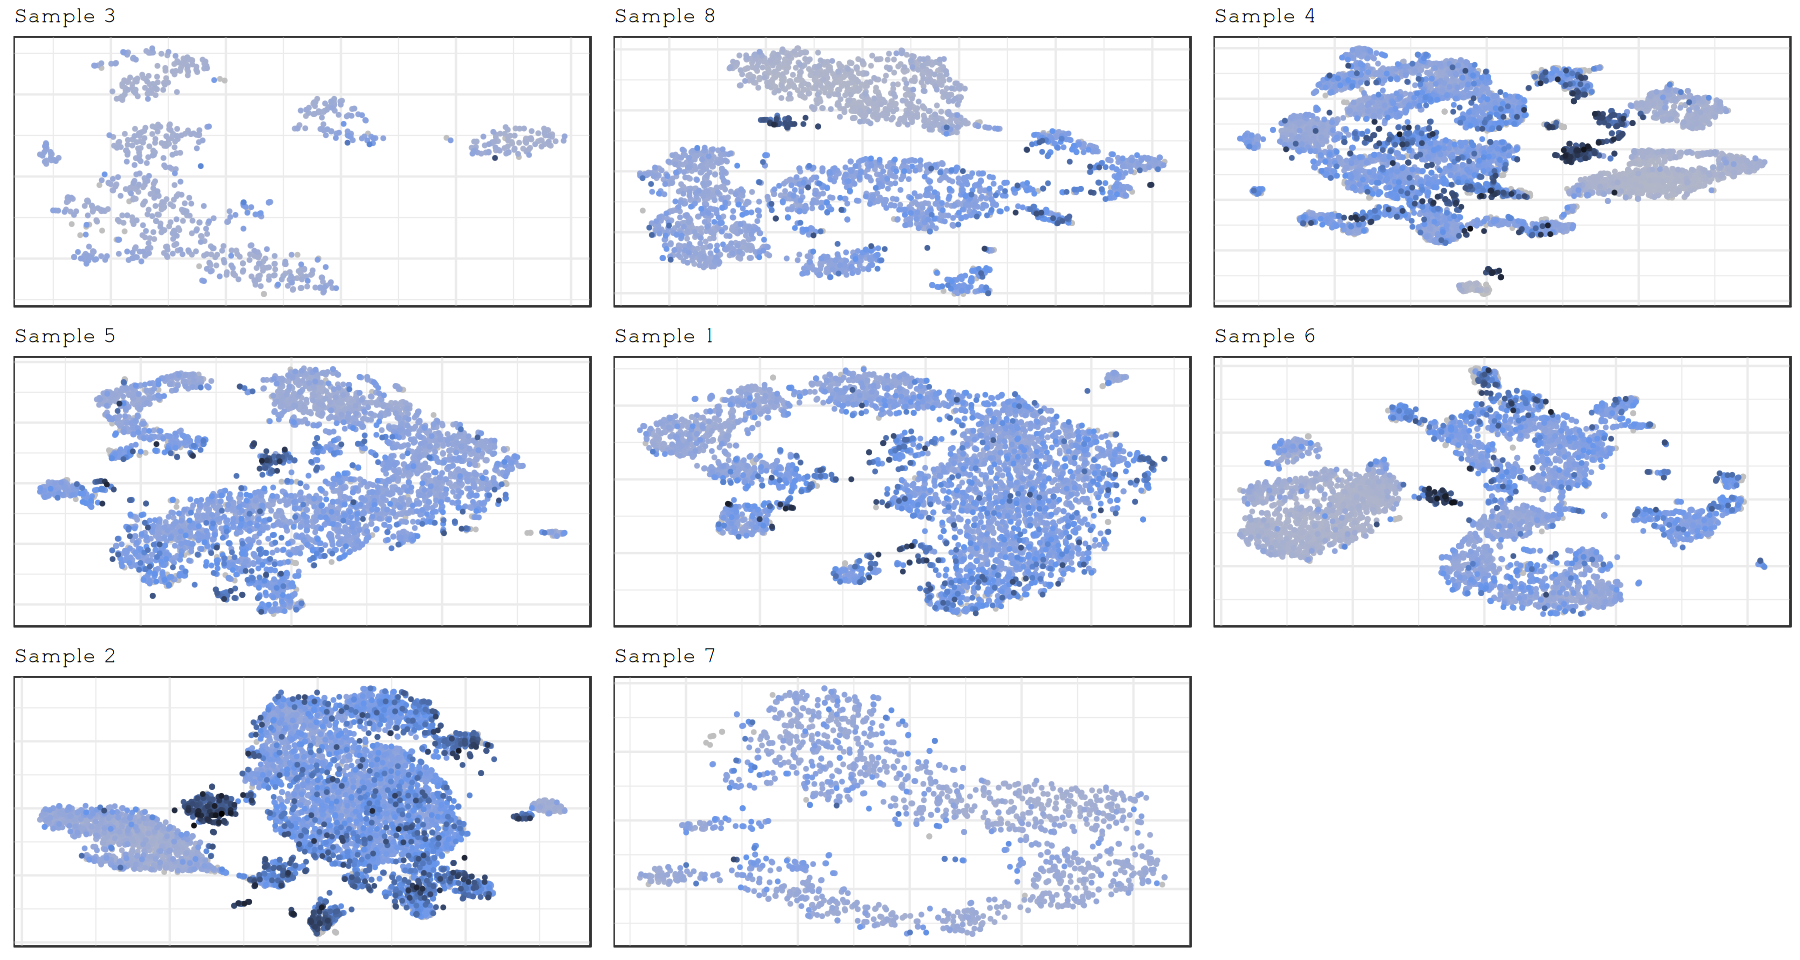

In [10]:
tsnes = lapply(unique(meta$sample), function(x){
  sub = scater::logNormCounts(sce[, meta$sample == x])
  hvgs = getHVGs(sub, block=NULL)
  pca = prcomp_irlba(t(logcounts(sub[hvgs,])), n = 50)
  tsne = Rtsne(pca$x, pca = FALSE)
 #   umap = run_umap(pca$x)
  return(tsne$Y)
 #   return(umap)
})
names(tsnes) = unique(meta$sample)

colmax = max(log2(scores + 1))

score_plots = lapply(unique(meta$sample), function(x){
  
  scr = log2(scores[meta$sample == x] + 1)
  ord = order(scr)
  p = ggplot(as.data.frame(tsnes[[as.character(x)]])[ord,],
         aes(x = V1, y= V2, col = scr[ord])) +
    geom_point(size = 0.6) +
    scale_color_gradient2(name = "log2(score+1)", mid = "cornflowerblue", low = "gray75", high = "black", midpoint = max(colmax)/2) +
    # scale_color_viridis() +
    ggtitle(paste0("Sample ", x)) +
    theme_bw() + 
    theme(legend.position = "none",
          axis.line = element_blank(),
          axis.ticks = element_blank(),
          axis.text = element_blank(),
          axis.title = element_blank(),
          panel.background = element_rect(colour = "black", linetype = 1, size = 0.5))
  
  return(p)
})

plot_grid(plotlist = score_plots)

In [12]:
clusters = lapply(unique(meta$sample), function(x){
  sub_sce = scater::logNormCounts(sce[,meta$sample == x])
  sub_meta = meta[meta$sample == x,]

  graph = buildSNNGraph(sub_sce)
  clusters = cluster_louvain(graph)

  vec = as.numeric(membership(clusters))
  names(vec) = sub_meta$cell
  return(vec)
})

names(clusters) = unique(meta$sample)
clusters_sub = lapply(unique(meta$sample), function(x){
  sub_sce = scater::logNormCounts(sce[,meta$sample == x])
  sub_meta = meta[meta$sample == x,]
  clusts = clusters[[as.character(x)]]

  sub_clusts = lapply(unique(clusts), function(y){
    sub_sub_sce = scater::logNormCounts(sub_sce[,clusts == y])
    sub_sub_meta = sub_meta[clusts == y,]

    graph = buildSNNGraph(sub_sub_sce, d = min(c(ncol(sub_sub_sce)-1, 50)))
    clusters = cluster_louvain(graph)

    vec = as.numeric(membership(clusters))
    vec = paste0(y, ".", vec)
    names(vec) = sub_sub_meta$cell
    return(vec)
  })

  clusts = do.call(c, sub_clusts)
  clusts = clusts[match(meta$cell[meta$sample == x], names(clusts))]
  return(clusts)
})

clusters = do.call(c, clusters)
clusters_sub = do.call(c, clusters_sub)
clusters = clusters_sub
meta$doub.density = scores


Warning message in (function (A, nv = 5, nu = nv, maxit = 1000, work = nv + 7, reorth = TRUE, :
“You're computing too large a percentage of total singular values, use a standard svd instead.”
Warning message in (function (A, nv = 5, nu = nv, maxit = 1000, work = nv + 7, reorth = TRUE, :
“You're computing too large a percentage of total singular values, use a standard svd instead.”
Warning message in (function (A, nv = 5, nu = nv, maxit = 1000, work = nv + 7, reorth = TRUE, :
“You're computing too large a percentage of total singular values, use a standard svd instead.”
Warning message in (function (A, nv = 5, nu = nv, maxit = 1000, work = nv + 7, reorth = TRUE, :
“You're computing too large a percentage of total singular values, use a standard svd instead.”
Warning message in (function (A, nv = 5, nu = nv, maxit = 1000, work = nv + 7, reorth = TRUE, :
“You're computing too large a percentage of total singular values, use a standard svd instead.”
Warning message in (function (A, nv = 5,

Warning message in max(log2(scores[meta$sample == 23] + 1)):
“no non-missing arguments to max; returning -Inf”


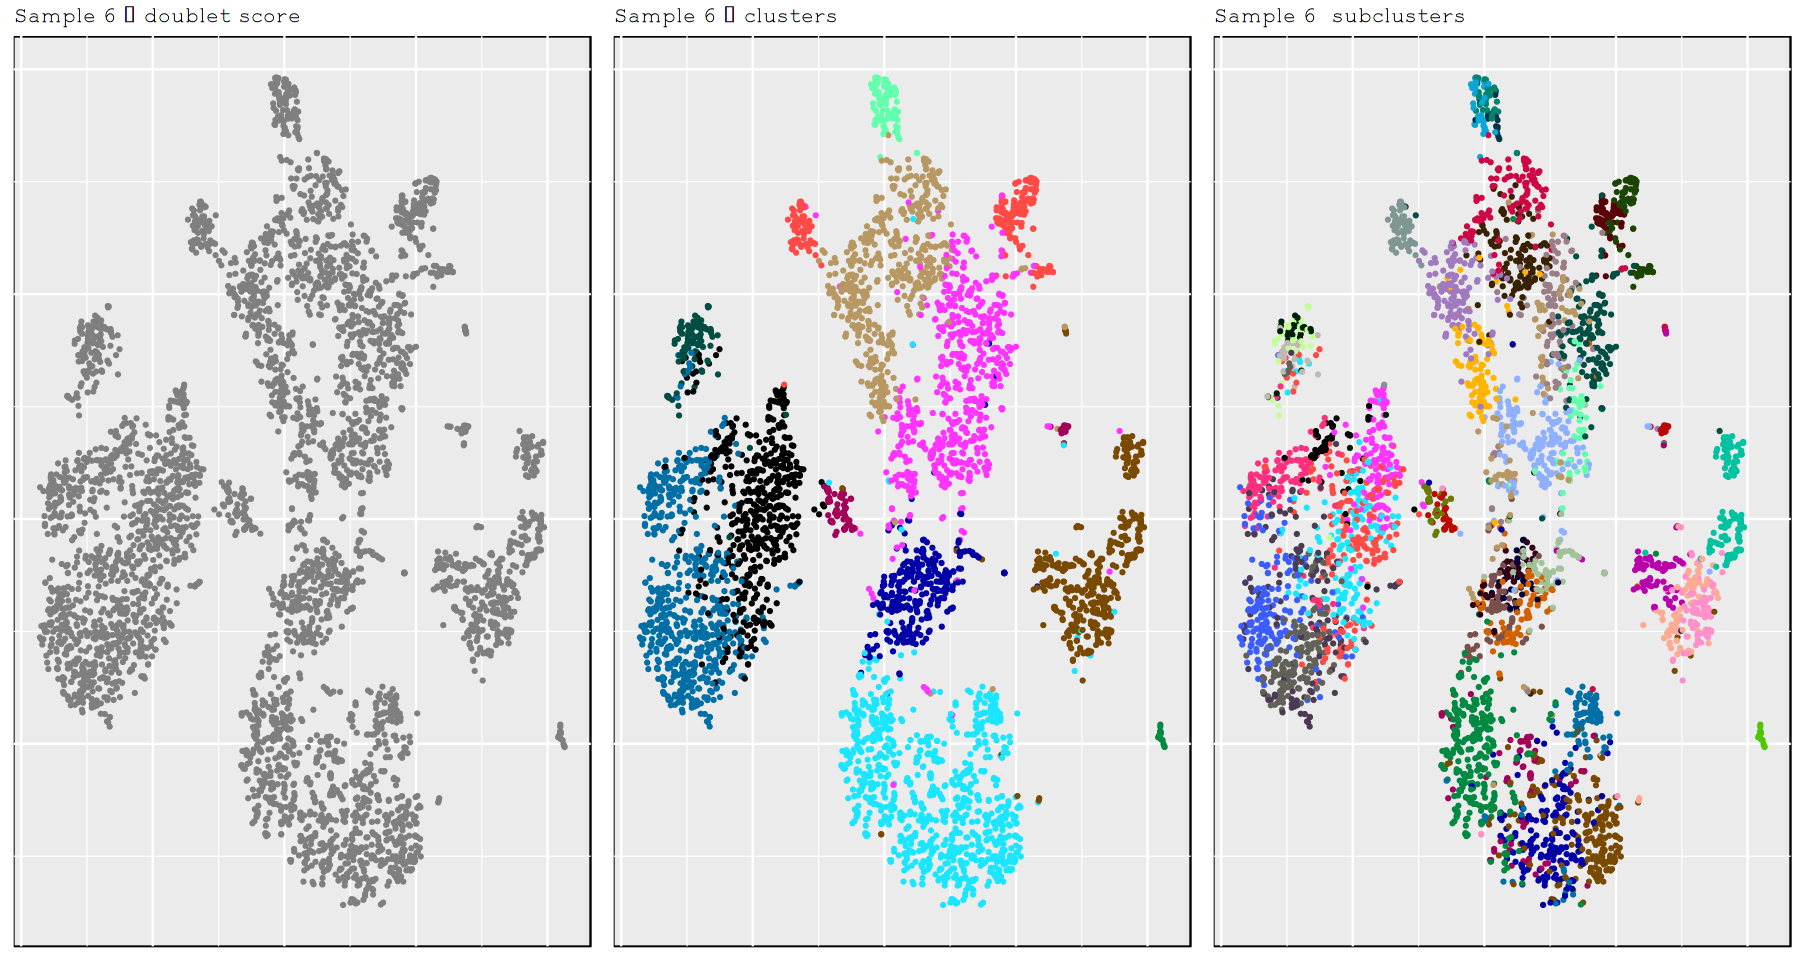

In [15]:
sample = 6

ord = order(scores[meta$sample == sample])
p1 = ggplot(as.data.frame(tsnes[[as.character(sample)]])[ord,], aes(x = V1, y= V2, col = log2(scores[meta$sample == sample]+1)[ord])) +
  geom_point(size = 0.7) +
  ggtitle(paste0("Sample ", sample, " - doublet score")) +
    theme(legend.position = "none",
          axis.line = element_blank(),
          axis.ticks = element_blank(),
          axis.text = element_blank(),
          axis.title = element_blank(),
          panel.background = element_rect(colour = "black", linetype = 1, size = 0.5)) +
  # scale_color_viridis() +
  scale_color_gradient2(name = "log2(score+1)", mid = "cornflowerblue", low = "gray75", high = "black", midpoint = max(log2(scores[meta$sample == 23]+1))/2)

col2 = regmatches(clusters[meta$sample == sample], regexpr("[0-9]+", clusters[meta$sample == sample]))

p2 = ggplot(as.data.frame(tsnes[[as.character(sample)]])[ord,], aes(x = V1, y= V2, col = factor(col2)[ord])) +
  geom_point(size = 0.7) +
  ggtitle(paste0("Sample ", sample, " - clusters")) +
    theme(legend.position = "none",
          axis.line = element_blank(),
          axis.ticks = element_blank(),
          axis.text = element_blank(),
          axis.title = element_blank(),
          panel.background = element_rect(colour = "black", linetype = 1, size = 0.5)) +
  scale_colour_Publication()

p3 = ggplot(as.data.frame(tsnes[[as.character(sample)]])[ord,], aes(x = V1, y= V2, col = factor(clusters[meta$sample == sample])[ord])) +
  geom_point(size = 0.7) +
  ggtitle(paste0("Sample ", sample, "  subclusters")) +
    theme(legend.position = "none",
          axis.line = element_blank(),
          axis.ticks = element_blank(),
          axis.text = element_blank(),
          axis.title = element_blank(),
          panel.background = element_rect(colour = "black", linetype = 1, size = 0.5)) +
  scale_colour_Publication()

plot_grid(p1, p2, p3, nrow = 1)

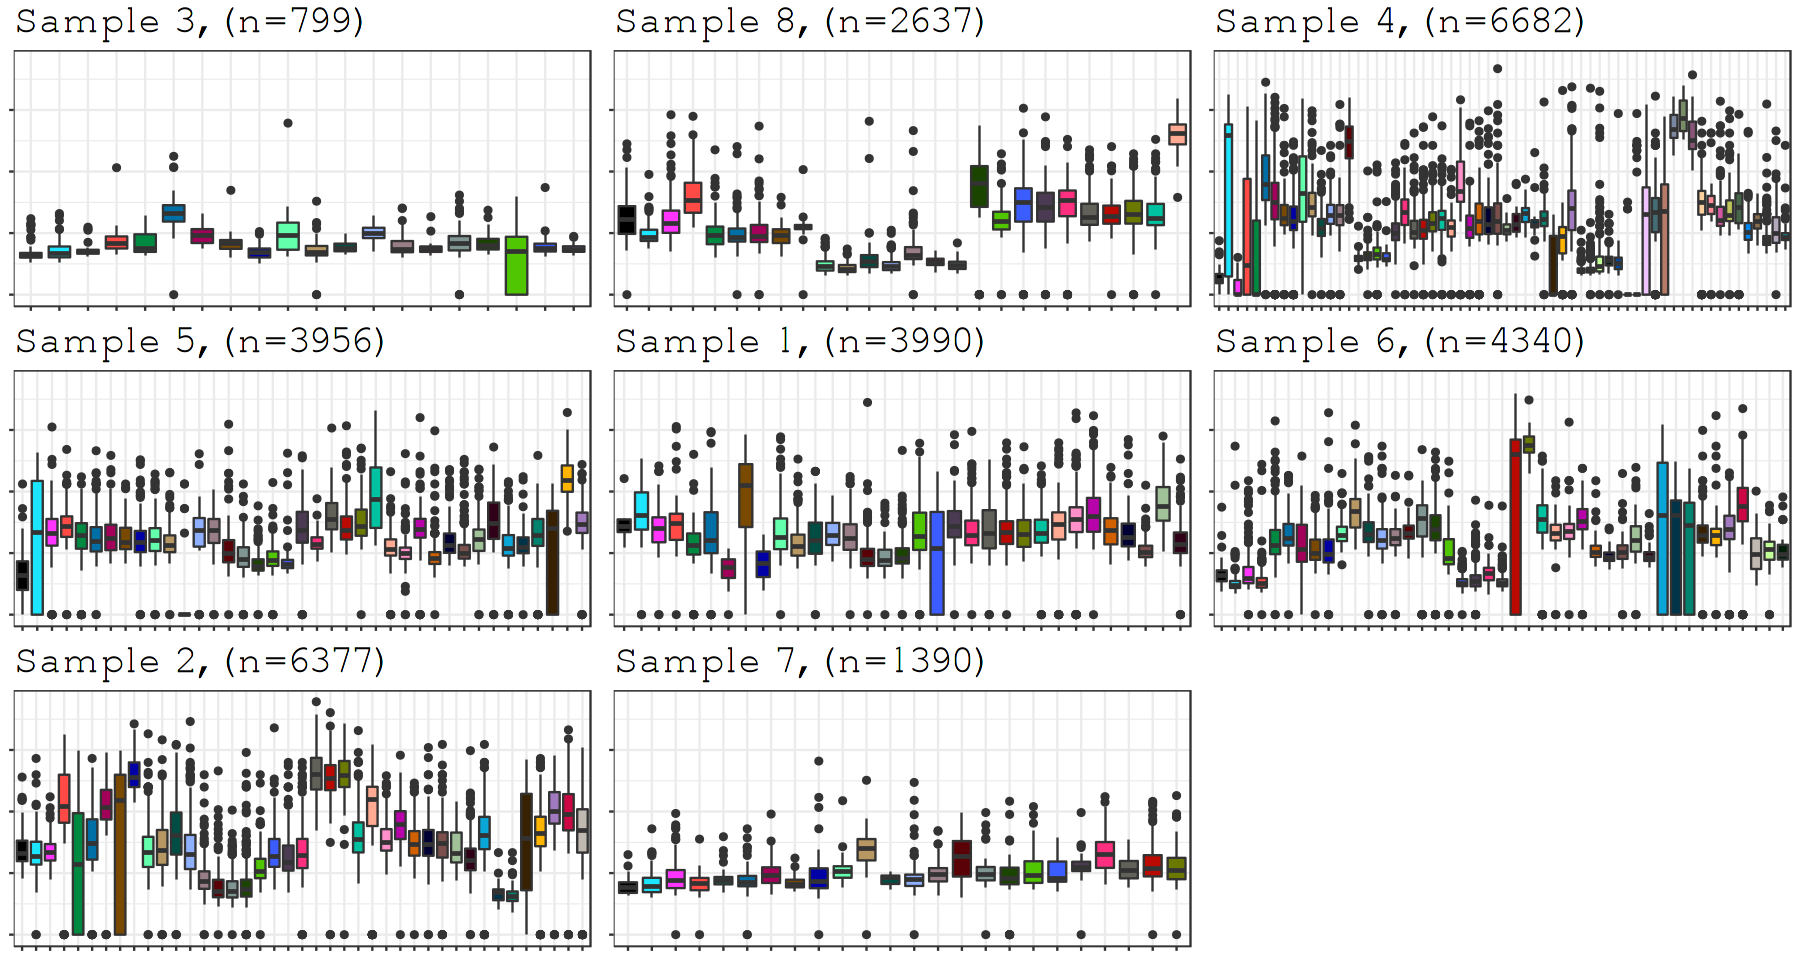

In [16]:
maxscore = max(log2(scores+1))

plots = lapply(unique(meta$sample), function(x){
  
  p = ggplot(data = data.frame(clusts = clusters[meta$sample == x],
                           scores = log2(scores[meta$sample == x] + 1)),
         mapping = aes(x = factor(clusts), y=scores, fill = factor(clusts))) +
    geom_boxplot() +
    theme_bw() + 
    theme(axis.text = element_blank(),
          axis.title = element_blank(),
          text = element_text(size=20),
          legend.position = "none") +
    lims(y = c(0, maxscore)) +
    scale_fill_Publication() +
    ggtitle(paste0("Sample ", x, ", (n=", sampsize$value[match(x, sampsize$Var1)], ")"))
  
  return(p)
})

plot_grid(plotlist = plots, ncol = 3)

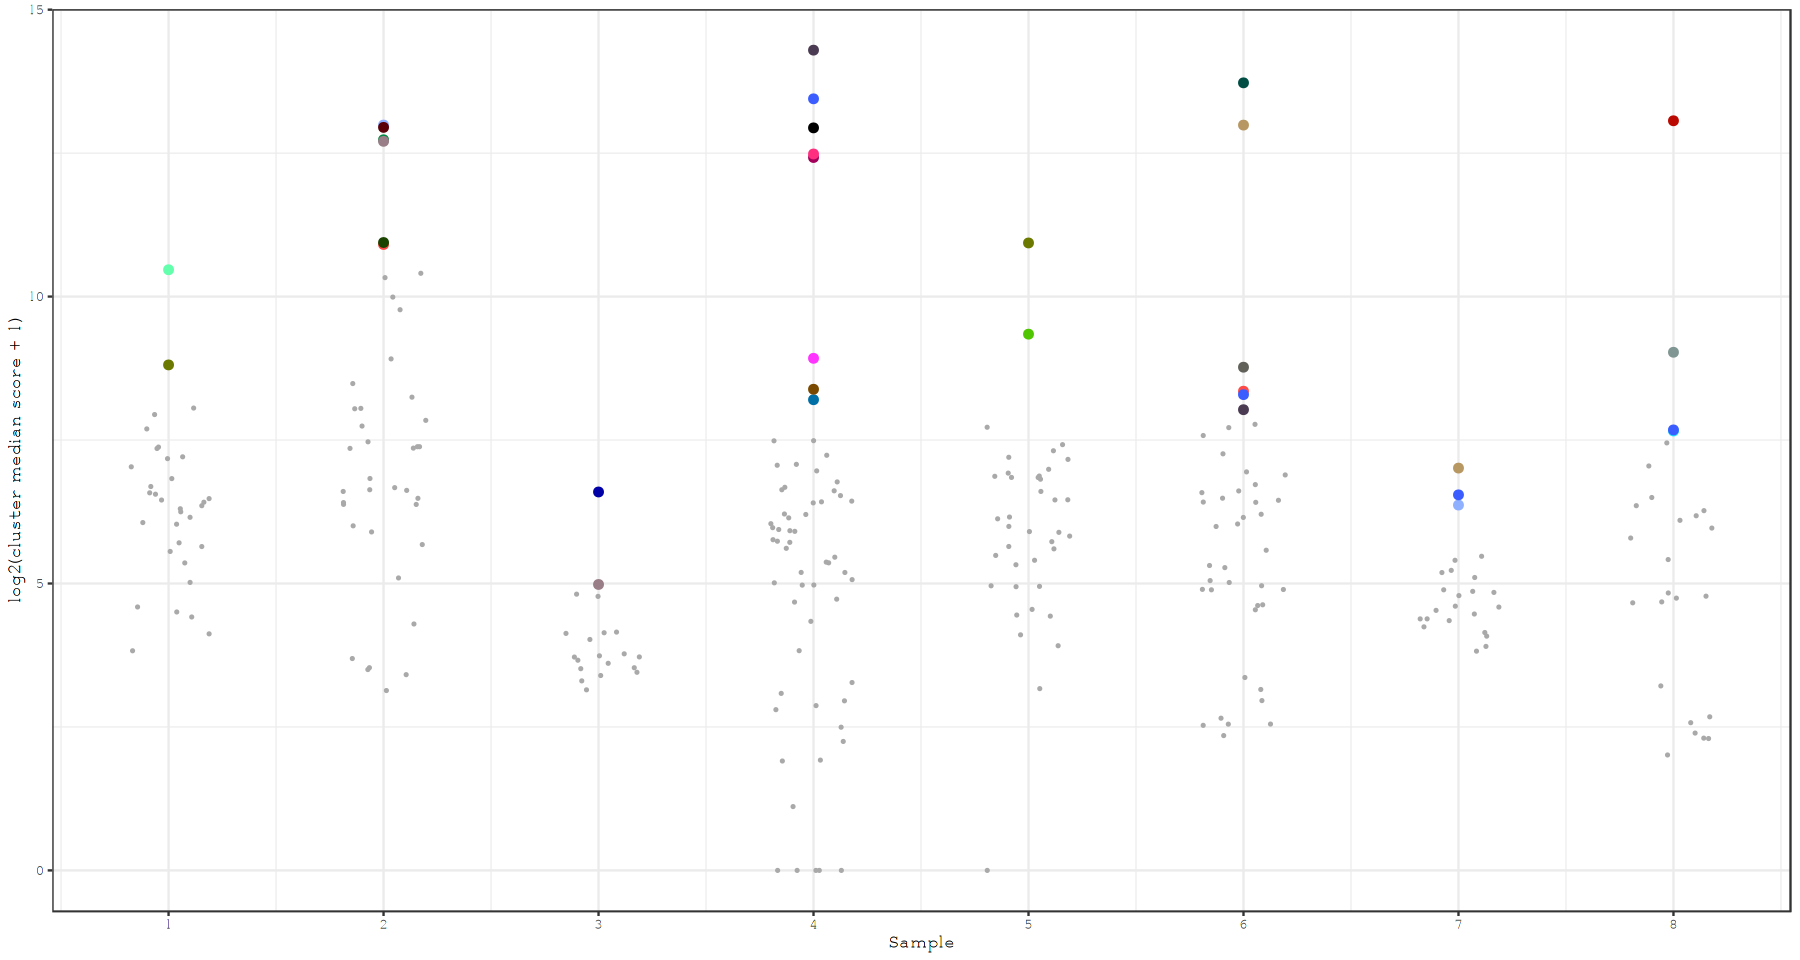

In [17]:
pdf = aggregate(meta$doub.density, list(meta$sample, clusters), median)

names(pdf) = c("sample", "cluster", "median.score")

mad_upper = function(x){
  x = x-median(x)
  return(mad(x[x>0], center = 0))
}

tests = lapply(unique(meta$sample), function(x){
  sub = pdf[pdf$sample == x,]
  scores_sample = meta$doub.density[meta$sample == x]
  sub$p.value = pnorm(sub$median.score, mean = median(sub$median.score), sd = mad_upper(sub$median.score), lower.tail = FALSE)
  return(sub)
})
pdf = do.call(rbind, tests)
pdf$fdr = p.adjust(pdf$p.value, method = "fdr")
pdf$n.cells = sapply(1:nrow(pdf), function(row){
  sum(clusters == pdf$cluster[row] & meta$sample == pdf$sample[row])
})

pdf$frac.cells = sapply(1:nrow(pdf), function(row){
  pdf$n.cells[row]/sum(pdf$n.cells[pdf$sample == pdf$sample[row]])
})



ggplot(pdf, aes(x = sample, y = log2(median.score + 1), col = factor(cluster))) +
  geom_point(data = pdf[pdf$fdr < 0.1,], size = 2) +
  geom_jitter(data = pdf[pdf$fdr >= 0.1,], col = "darkgrey", size = 0.4, width = 0.2, height = 0) +
  scale_colour_Publication() +
  theme_bw() +
  theme(legend.position = "none") +
  scale_x_continuous(breaks = 1:max(pdf$sample)) +
  labs(x = "Sample", y = "log2(cluster median score + 1)")

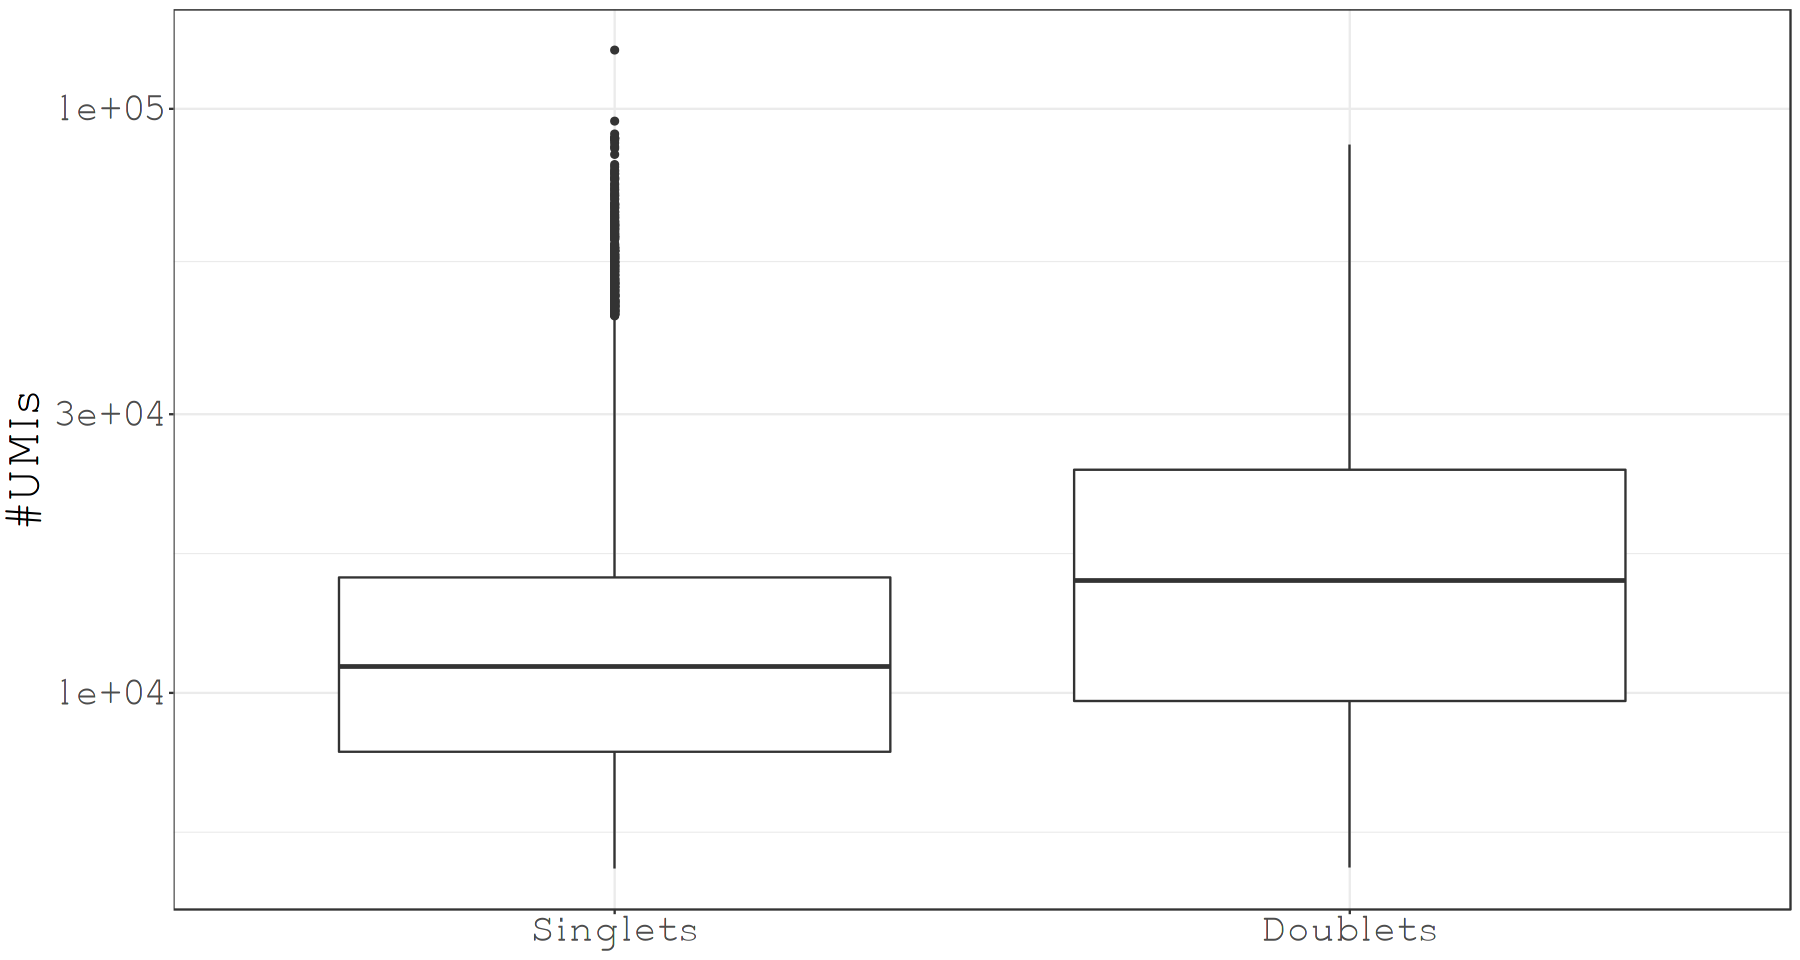

In [18]:
doub.call = paste(meta$sample, clusters) %in% paste(pdf$sample, pdf$cluster)[pdf$fdr < 0.1]

libs = Matrix::colSums(counts(sce))

ggplot(mapping = aes(x = doub.call, y = libs)) +
  geom_boxplot() +
  scale_x_discrete(labels = c("FALSE" = "Singlets", "TRUE" = "Doublets")) +
  theme_bw() +
  theme(axis.title.x = element_blank(), text = element_text(size=30)) +
  labs(y = "#UMIs") +
  scale_y_log10()

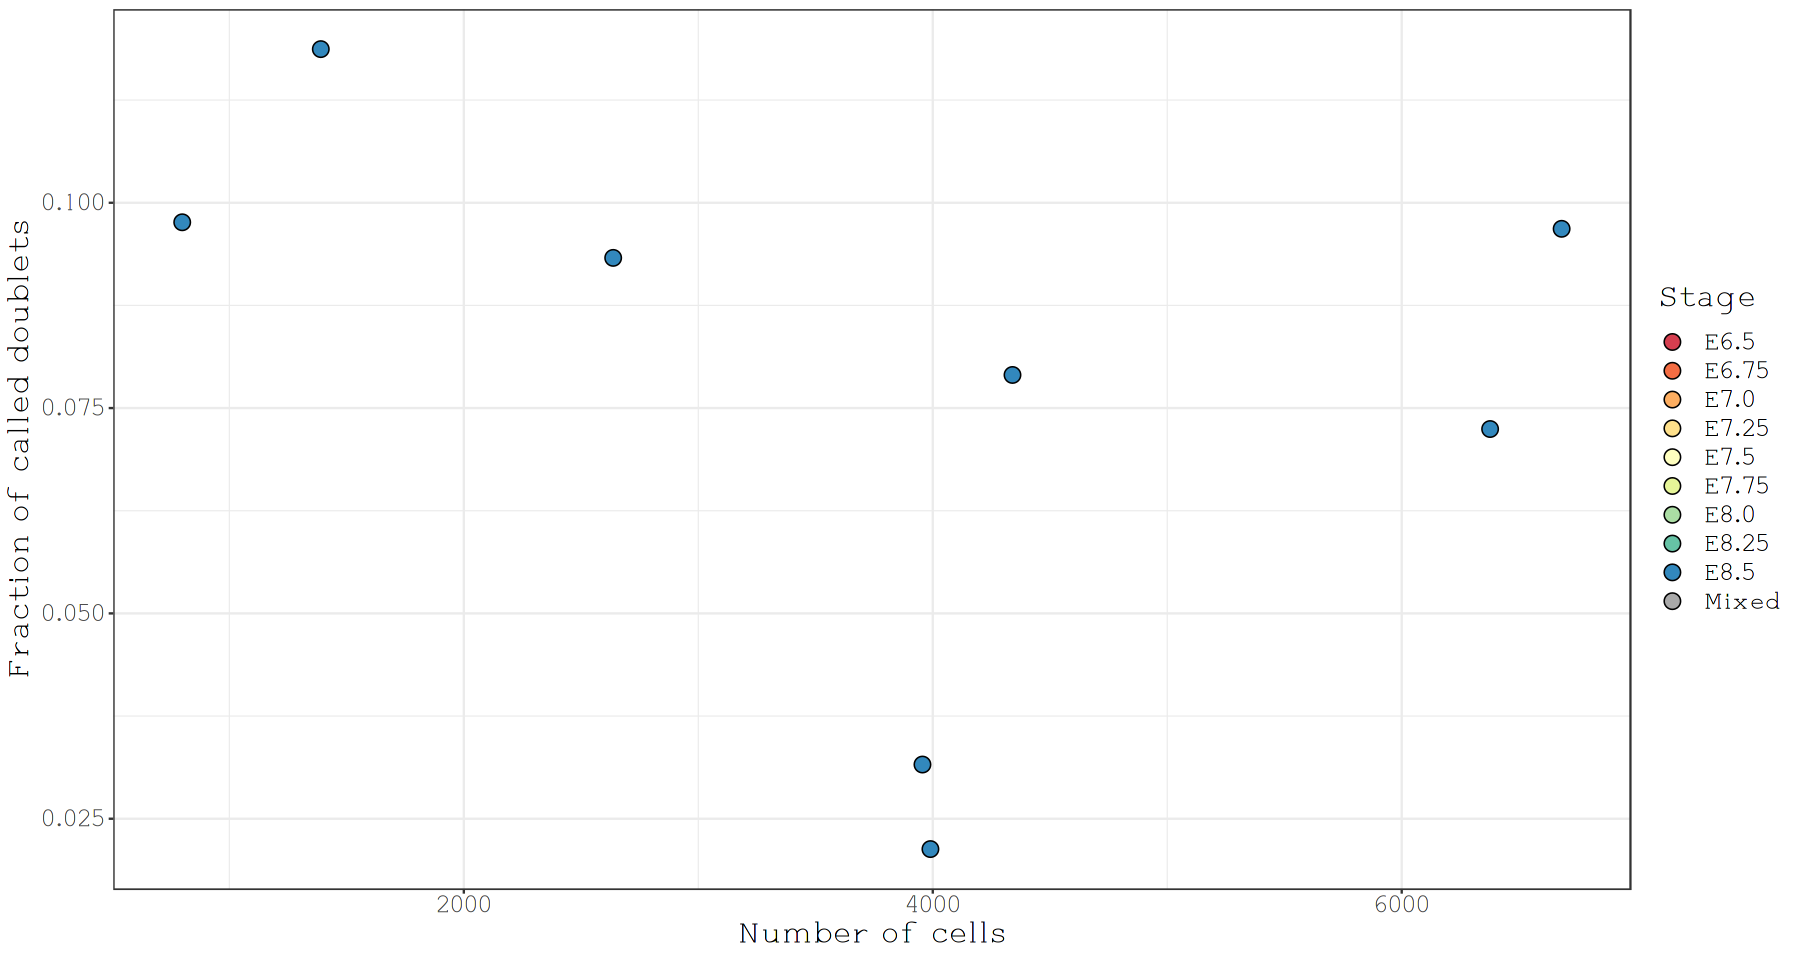

In [20]:
fd = sapply(unique(meta$sample), function(x){
  sum(doub.call[meta$sample == x])/sum(meta$sample == x)
})

nc = sapply(unique(meta$sample), function(x){
  sum(meta$sample == x)
})

frac_doubs = ggplot(mapping = aes(x = nc, y = fd, fill = meta$stage[match(unique(meta$sample), meta$sample)])) + 
  geom_point(shape = 21, size = 4, alpha = 1) +
  scale_fill_manual(values = stage_colours, labels = stage_labels, name = "Stage") +
  labs(x = "Number of cells", y = "Fraction of called doublets") + 
  theme_bw() + theme(text = element_text(size=20))

frac_doubs

In [21]:
db = useMart("ensembl", dataset = "mmusculus_gene_ensembl")
gene_map = getBM(attributes = c("ensembl_gene_id", "external_gene_name"), filters = "ensembl_gene_id", values = genes[,1], mart = db)

colnames(gene_map) = c('V1', 'V2')
genes$index = 1:nrow(genes)
genes = merge(genes, gene_map, by= 'V1', all.x=TRUE)
genes = genes[order(genes$index), ]
genes$index = NULL

In [22]:
xist_on = counts(sce)[match("Xist", genes[,2]),]>0

#db = useMart("ensembl", dataset = "mmusculus_gene_ensembl")
sex_genes = read.table("/rds/project/rds-SDzz0CATGms/users/bt392/software/ygenes.tab", stringsAsFactors = FALSE)[,1]
sex_genes = sex_genes[sex_genes != "ENSMUSG00000096768"] #this gene has an X chromosome paralogue Erdr1 - exclude

y_on = Matrix::colSums(counts(sce)[match(sex_genes, genes[,1])[!is.na(match(sex_genes, genes[,1]))],] > 0 )>0

sex = xist_on & y_on

pdf$sex.frac = sapply(1:nrow(pdf), function(row){
  select = clusters == pdf$cluster[row] & meta$sample == pdf$sample[row]
  return(sum(sex[select])/sum(select))
})

pdf$stage = meta$stage[match(pdf$sample, meta$sample)]


pdf$call = pdf$fdr < 0.1

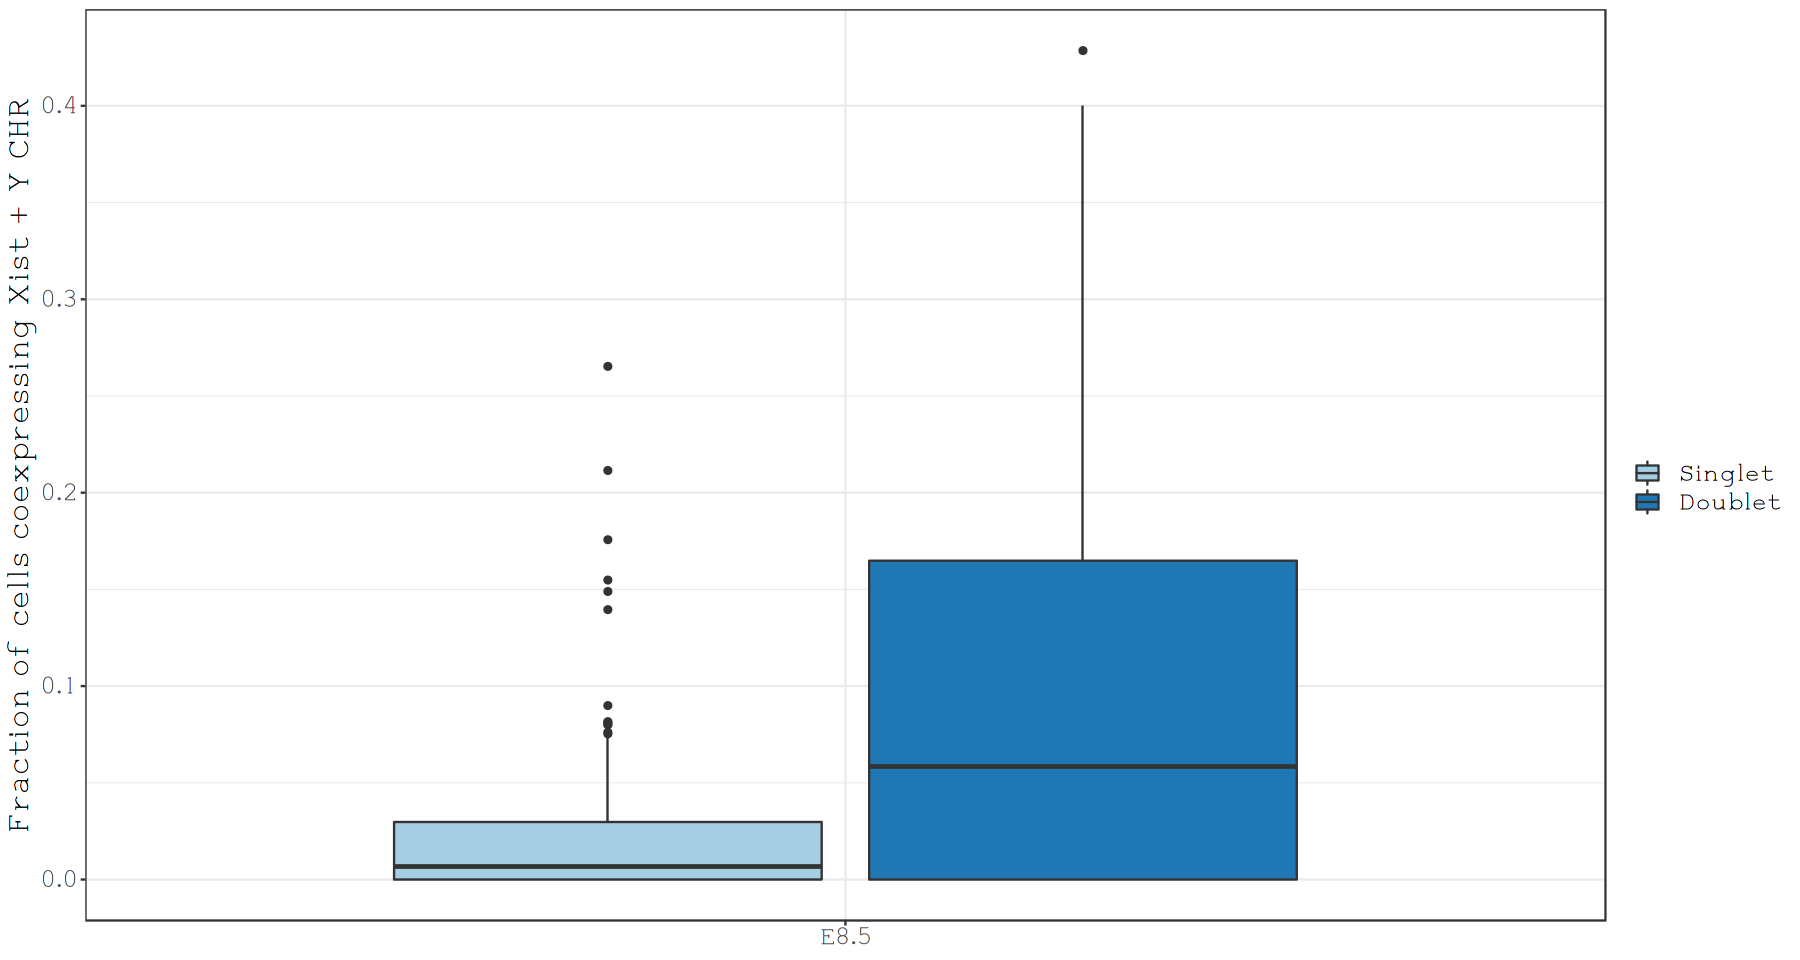

In [23]:

xist_plot = ggplot(pdf, aes(y = sex.frac, x = stage, fill = call)) +
  geom_boxplot() +
  scale_fill_brewer(palette = "Paired", labels = c("FALSE" = "Singlet", "TRUE" = "Doublet"), name = "") +
  theme_bw() +
  theme(axis.title.x = element_blank(), text = element_text(size=20)) +
  scale_x_discrete(labels = stage_labels) +
  labs(y = "Fraction of cells coexpressing Xist + Y CHR")

xist_plot

### Batch correction

In [25]:
hvgs = getHVGs(sce, block=meta$sample)

#get order: oldest to youngest; most cells to least cells
order_df = meta[!duplicated(meta$sample), c("stage", "sample")]
order_df$ncells = sapply(order_df$sample, function(x) sum(meta$sample == x))
order_df$stage = factor(order_df$stage, 
                        levels = rev(c(
                                    "E8.5"
                                      )))
order_df = order_df[order(order_df$stage, order_df$ncells, decreasing = TRUE),]
order_df$stage = as.character(order_df$stage)

all_correct = doBatchCorrect(counts = logcounts(sce)[rownames(sce) %in% hvgs,], 
                             timepoints = meta$stage, 
                             samples = meta$sample, 
                             timepoint_order = order_df$stage, 
                             sample_order = order_df$sample, 
                             npc = 50)

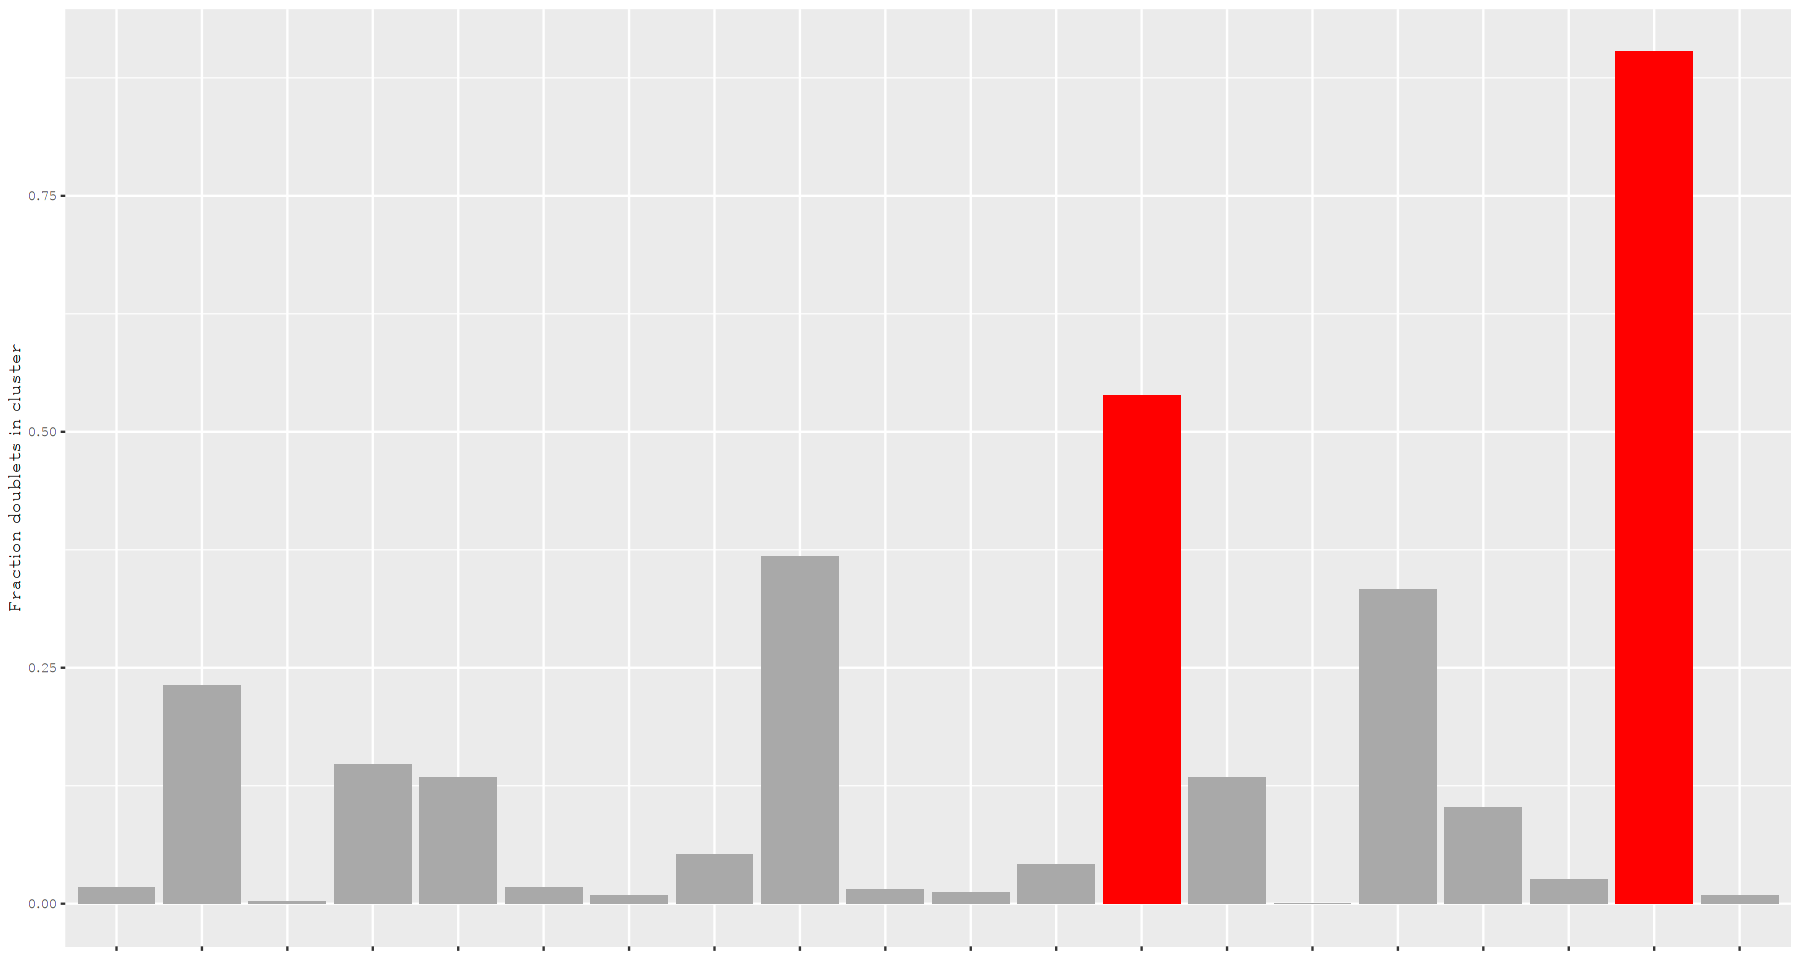

In [26]:
run_umap = function(pca_in){
    umap = umap_redu(pca_in)
    return(umap)    
}
tsne = run_umap(all_correct)

graph = buildSNNGraph(all_correct, d = NA, transposed = TRUE)
set.seed(42)
clusts = as.numeric(membership(cluster_louvain(graph)))
names(clusts) = meta$cell

tab = table(clusts, doub.call)
tab = as.data.frame(sweep(tab, 1, rowSums(tab), "/"))
tab = tab[as.logical(tab$doub.call),c(1,3)]
tab$p = pnorm(tab$Freq, mean = median(tab$Freq), sd = mad_upper(tab$Freq), lower.tail = FALSE)
tab$fdr = p.adjust(tab$p, method = "fdr")

ggplot(mapping = aes(x = factor(rownames(tab), levels = rownames(tab)), y = tab[,2], fill = tab$fdr < 0.1)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = c("TRUE" = "red", "FALSE" = "darkgrey")) +
  theme(legend.position = "none", axis.text.x = element_blank(), axis.title.x = element_blank()) +
  labs(y = "Fraction doublets in cluster")

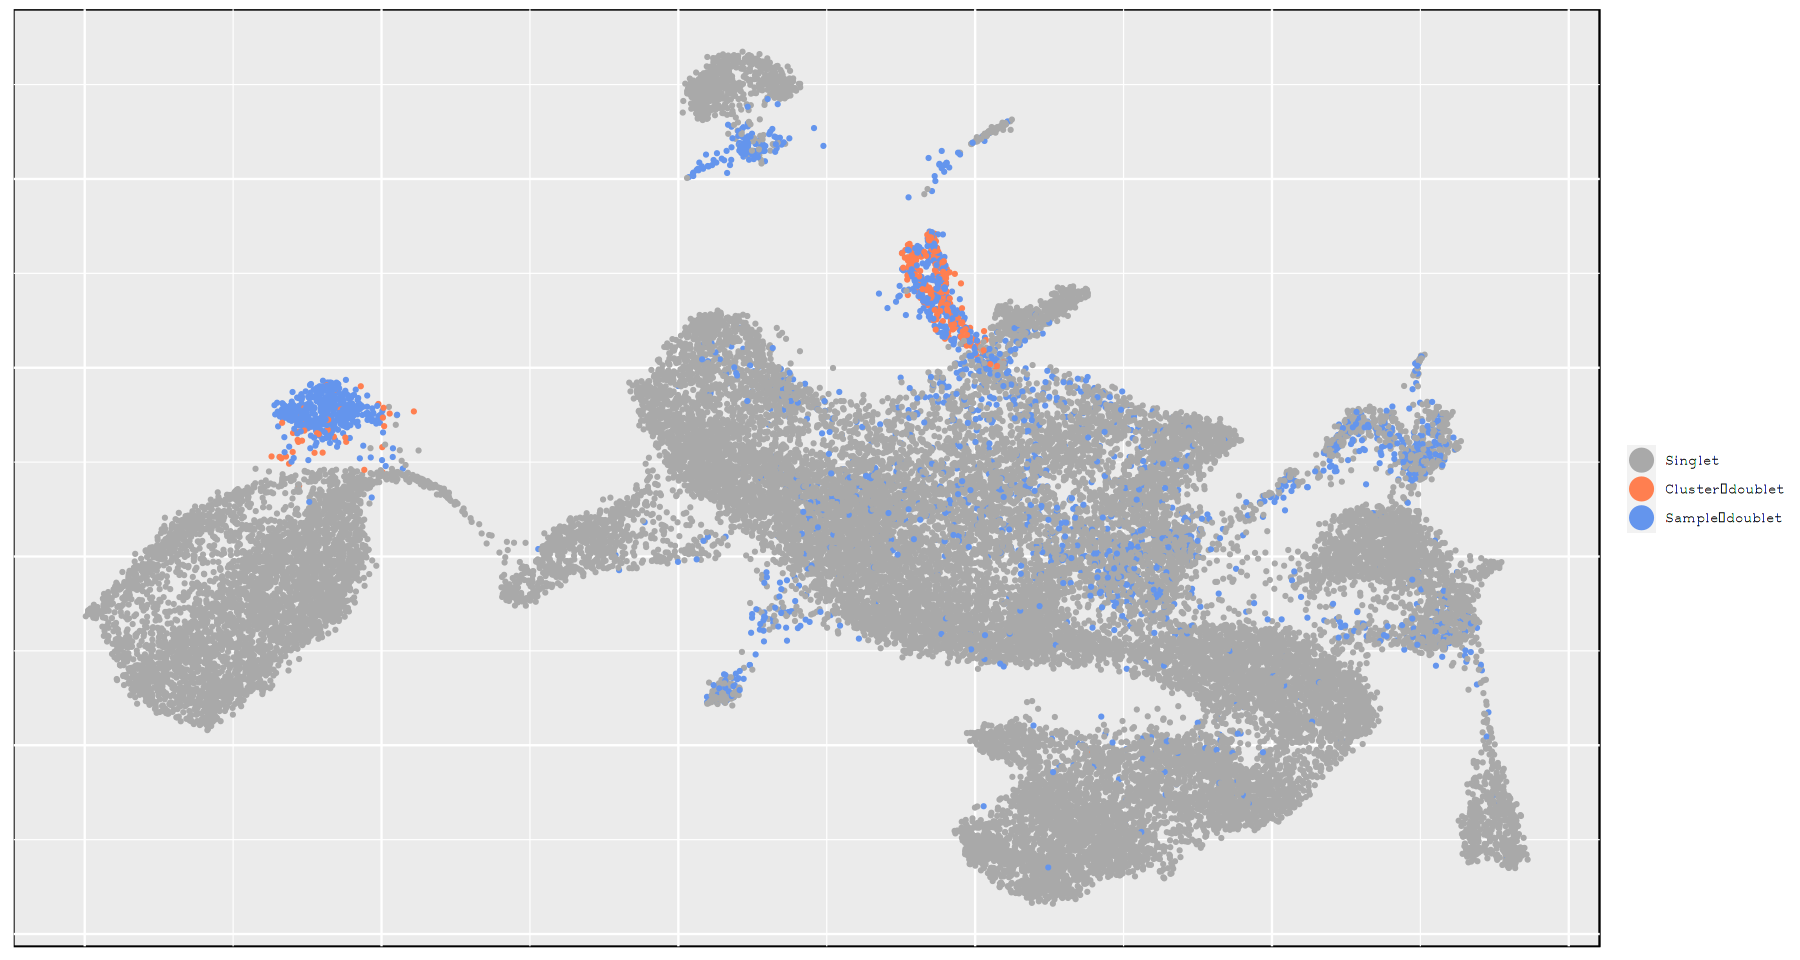

In [27]:
cluster_calls = clusts %in% tab$clusts[tab$fdr < 0.1]

cell_calls = doub.call
state = rep("Singlet", nrow(meta))
state[cluster_calls] = "Cluster-doublet"
state[cell_calls] = "Sample-doublet"

# ord = order(factor(state, levels = c("Singlet", "Cluster-doublet", "Sample-doublet")))
ord = sample(length(state), length(state))

ggplot(as.data.frame(tsne)[ord,], aes(x = V1, y= V2, col = state[ord])) +
    geom_point(size = 0.7) +
      theme(axis.line = element_blank(),
            axis.ticks = element_blank(),
            axis.text = element_blank(),
            axis.title = element_blank(),
            panel.background = element_rect(colour = "black", linetype = 1, size = 0.5)) +
    scale_colour_manual(values = c("Singlet" = "darkgrey", "Cluster-doublet" = "coral", "Sample-doublet" = "cornflowerblue"),
                        name = "") +
    guides(colour = guide_legend(override.aes = list(size=6)))

In [28]:
plots_calls = lapply(unique(meta$sample), function(x){
  keep = meta$sample == x
  ord = order(factor(state, levels = c("Singlet", "Cluster-doublet", "Sample-doublet")[keep]))
  state_sub = state[keep]
  ggplot(as.data.frame(tsnes[[as.character(x)]])[ord,], aes(x = V1, y= V2,
                                                                   col = state_sub[ord])) +
    geom_point(size = 0.7) +
    ggtitle(paste0("Sample ", x, " - calls")) +
      theme(legend.position = "none",
            axis.line = element_blank(),
            axis.ticks = element_blank(),
            axis.text = element_blank(),
            axis.title = element_blank(),
            panel.background = element_rect(colour = "black", linetype = 1, size = 0.5)) +
    scale_colour_manual(values = c("Singlet" = "darkgrey", "Cluster-doublet" = "coral", "Sample-doublet" = "cornflowerblue"))
})

grids = lapply(1:length(plots_calls), function(x) plot_grid(score_plots[[x]], plots_calls[[x]]))
grid = plot_grid(plotlist = grids, ncol =1)



Warning message:
“Removed 29372 rows containing missing values (geom_point).”
Warning message:
“Removed 27534 rows containing missing values (geom_point).”
Warning message:
“Removed 23489 rows containing missing values (geom_point).”
Warning message:
“Removed 26215 rows containing missing values (geom_point).”
Warning message:
“Removed 26181 rows containing missing values (geom_point).”
Warning message:
“Removed 25831 rows containing missing values (geom_point).”
Warning message:
“Removed 23794 rows containing missing values (geom_point).”
Warning message:
“Removed 28781 rows containing missing values (geom_point).”


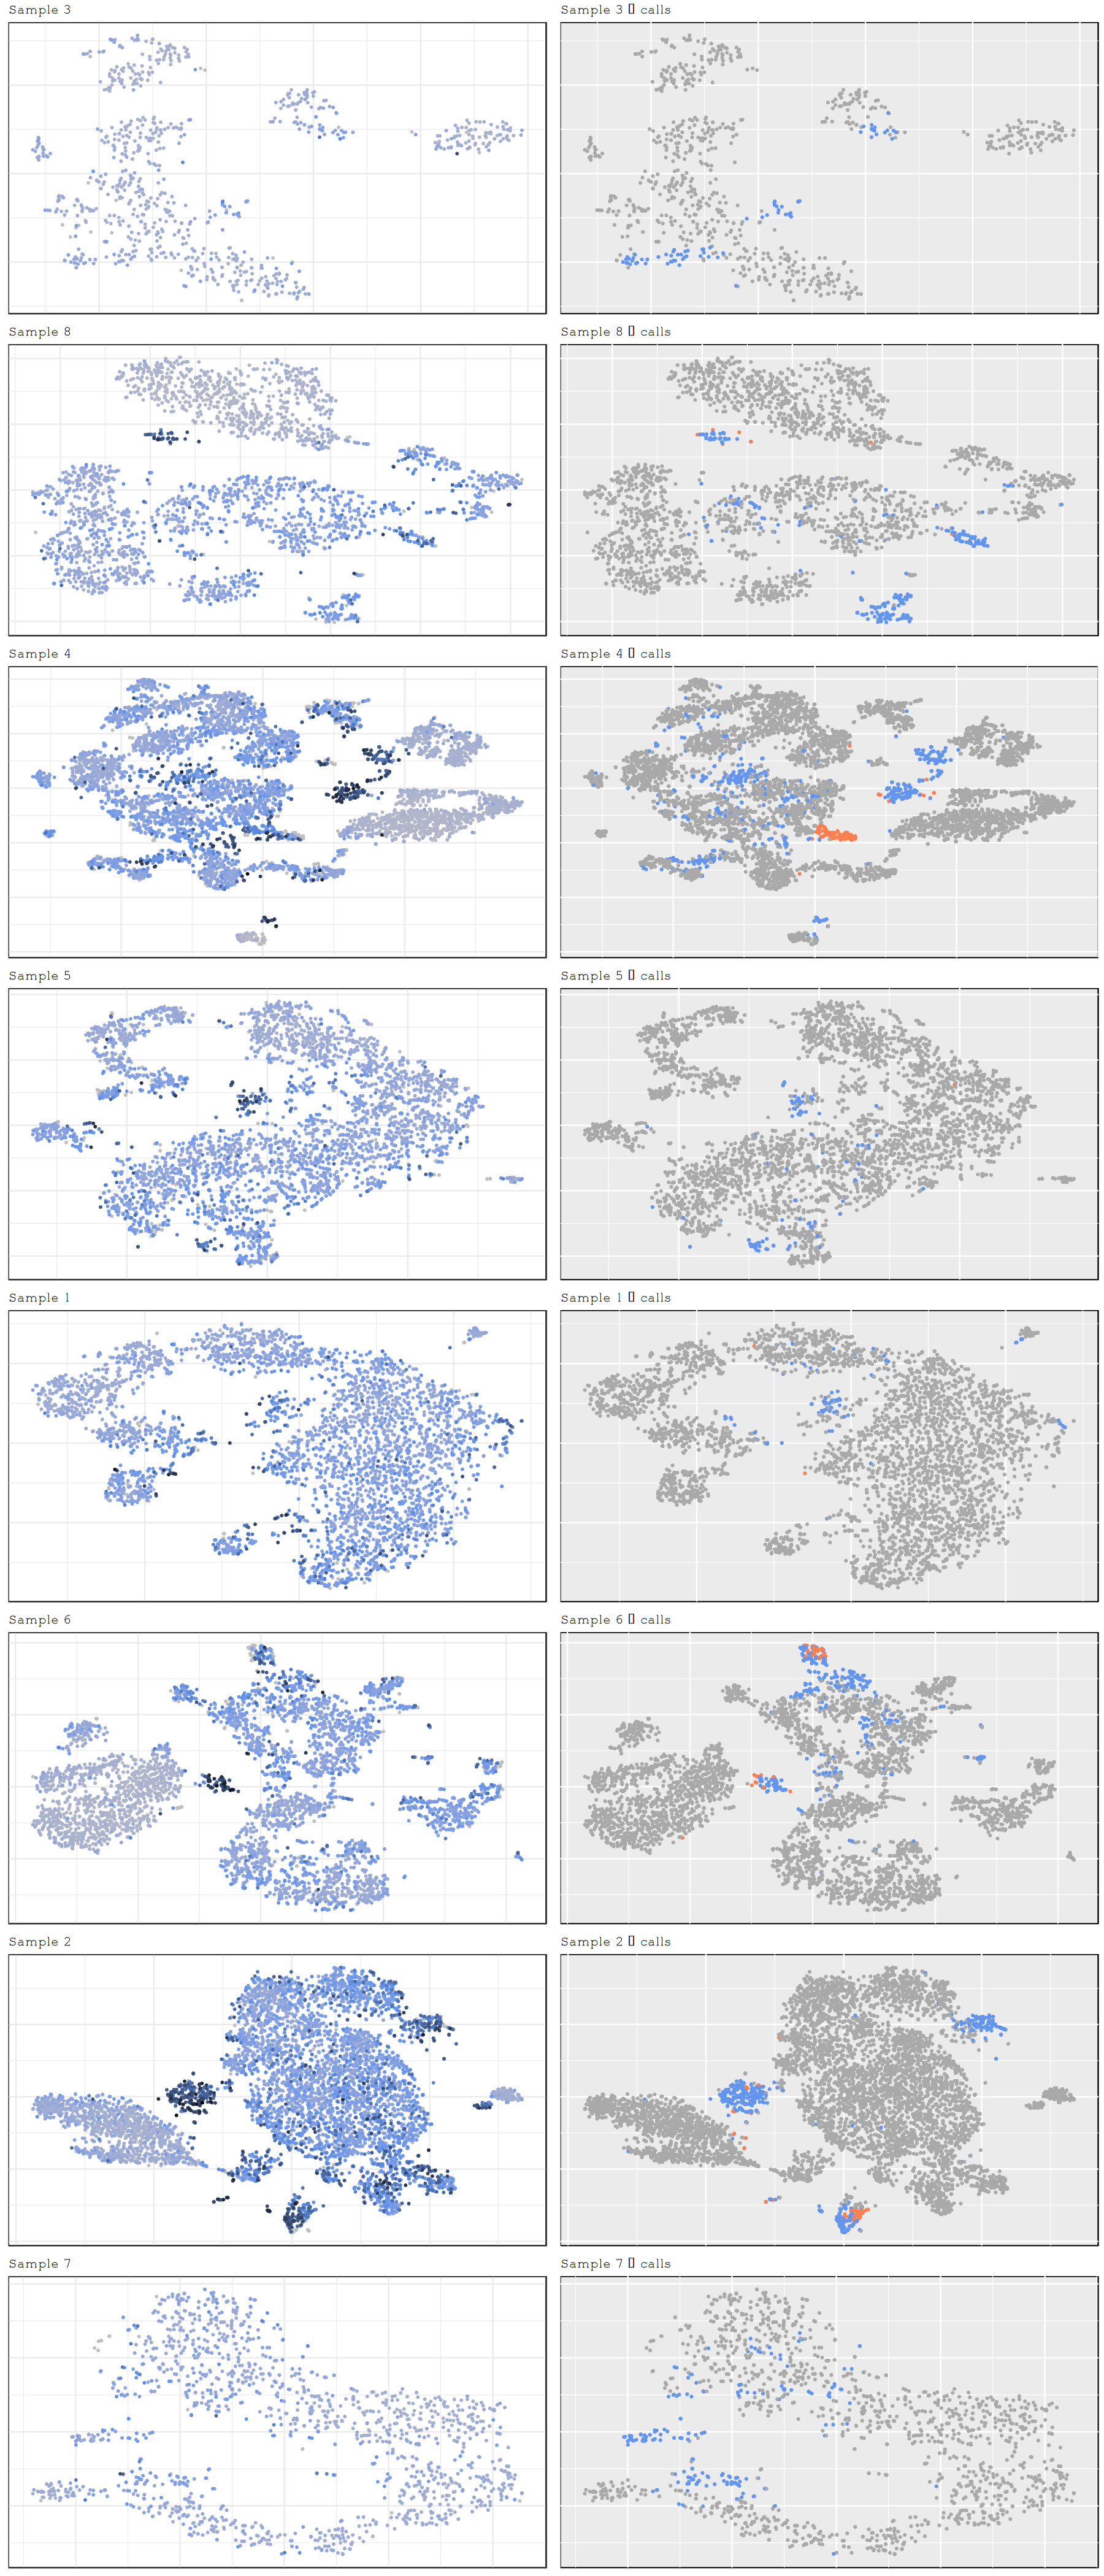

In [29]:
options(repr.plot.width=15, repr.plot.height=35)
suppressWarnings(plot(grid))

In [30]:
meta$doublet = state != "Singlet"

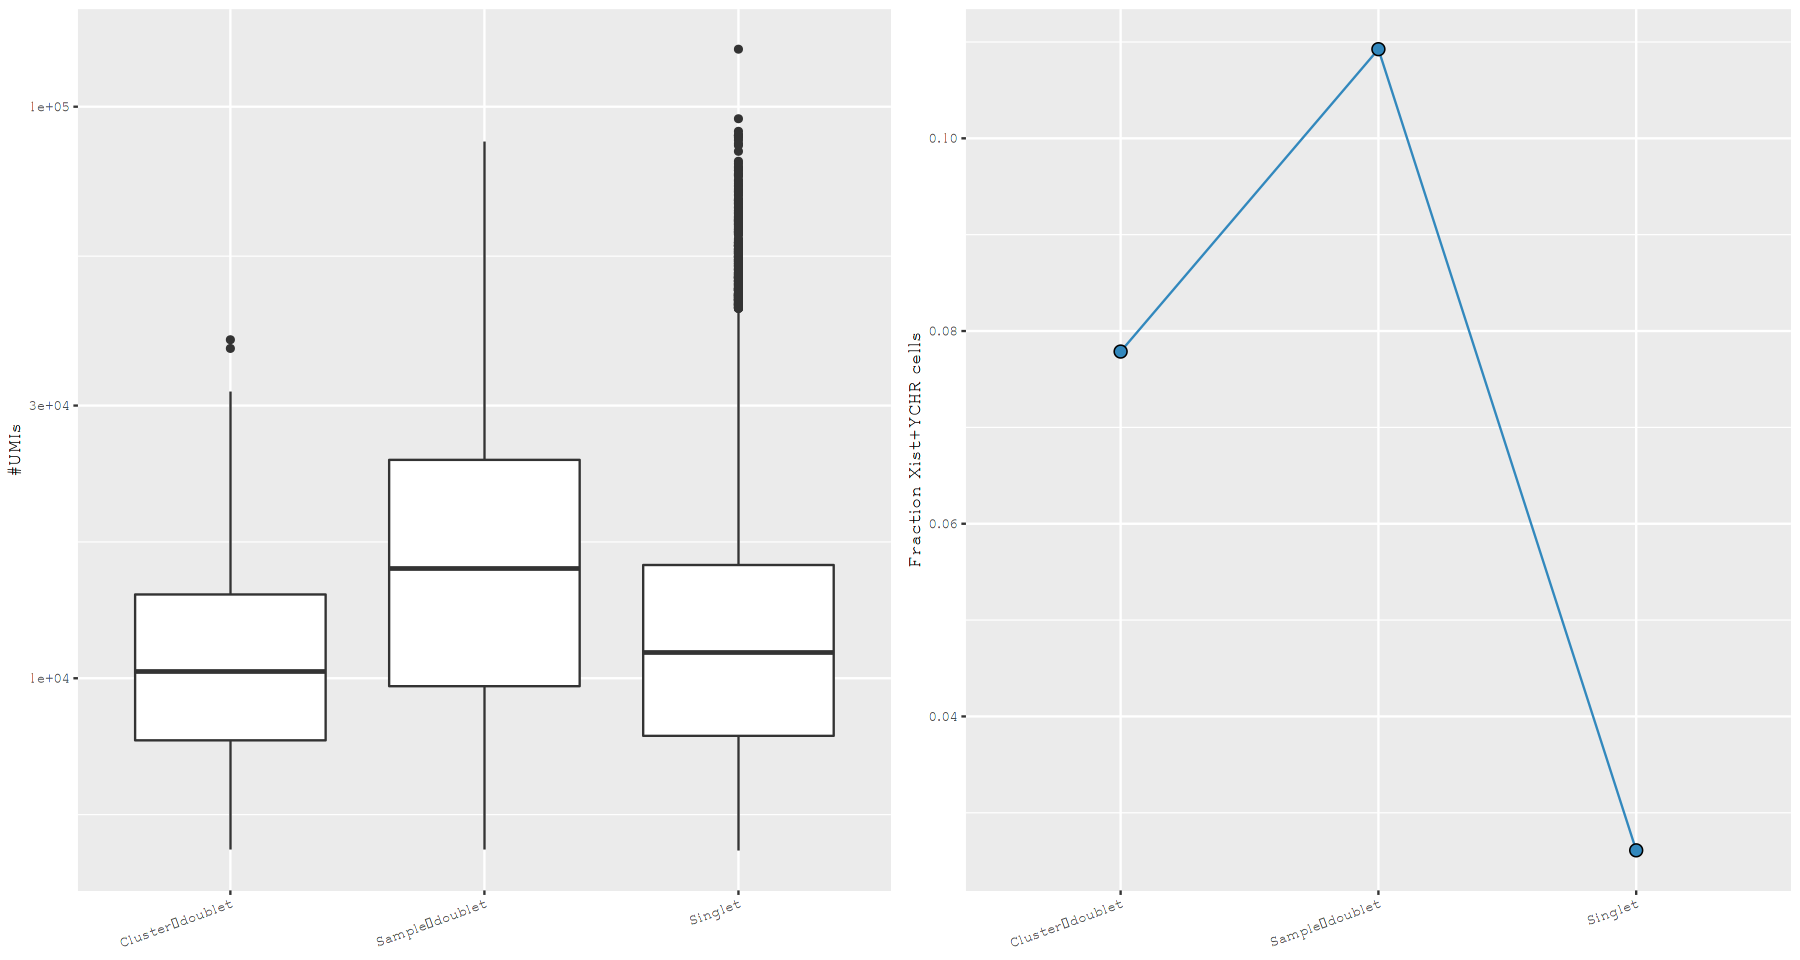

In [31]:
p1 = ggplot(mapping = aes(x = state, y = libs)) +
  geom_boxplot() +
  scale_x_discrete(labels = c("FALSE" = "Singlets", "TRUE" = "Doublets")) +
  theme(axis.title.x = element_blank()) +
  labs(y = "#UMIs") +
  scale_y_log10() +
  theme(axis.text.x = element_text(angle = 20, hjust = 1))

tab = table(sex, state, meta$stage)
tab = as.data.frame(tab)
tab$freq = sapply(1:nrow(tab), function(i){
  if(i %% 2 == 1){
    return(NA)
  } else {
    return(tab$Freq[i]/(tab$Freq[i] + tab$Freq[i-1]))
  }
})
tab = tab[as.logical(tab$sex), c(2,3,5)]

p2 = ggplot(tab, aes(x = state, y = freq, fill = Var3, group = Var3, col = Var3)) +
  scale_fill_manual(values = stage_colours, labels = stage_labels) +
  scale_colour_manual(values = stage_colours, labels = stage_labels) +
  geom_line() +
  geom_point(pch = 21, col = "black", size = 3) +
  theme(legend.position = "none",
        axis.title.x = element_blank()) +
  labs(y = "Fraction Xist+YCHR cells") +
  theme(axis.text.x = element_text(angle = 20, hjust = 1))

options(repr.plot.width=15, repr.plot.height=8)
plot_grid(p1,p2)

### Stripped Nuclei

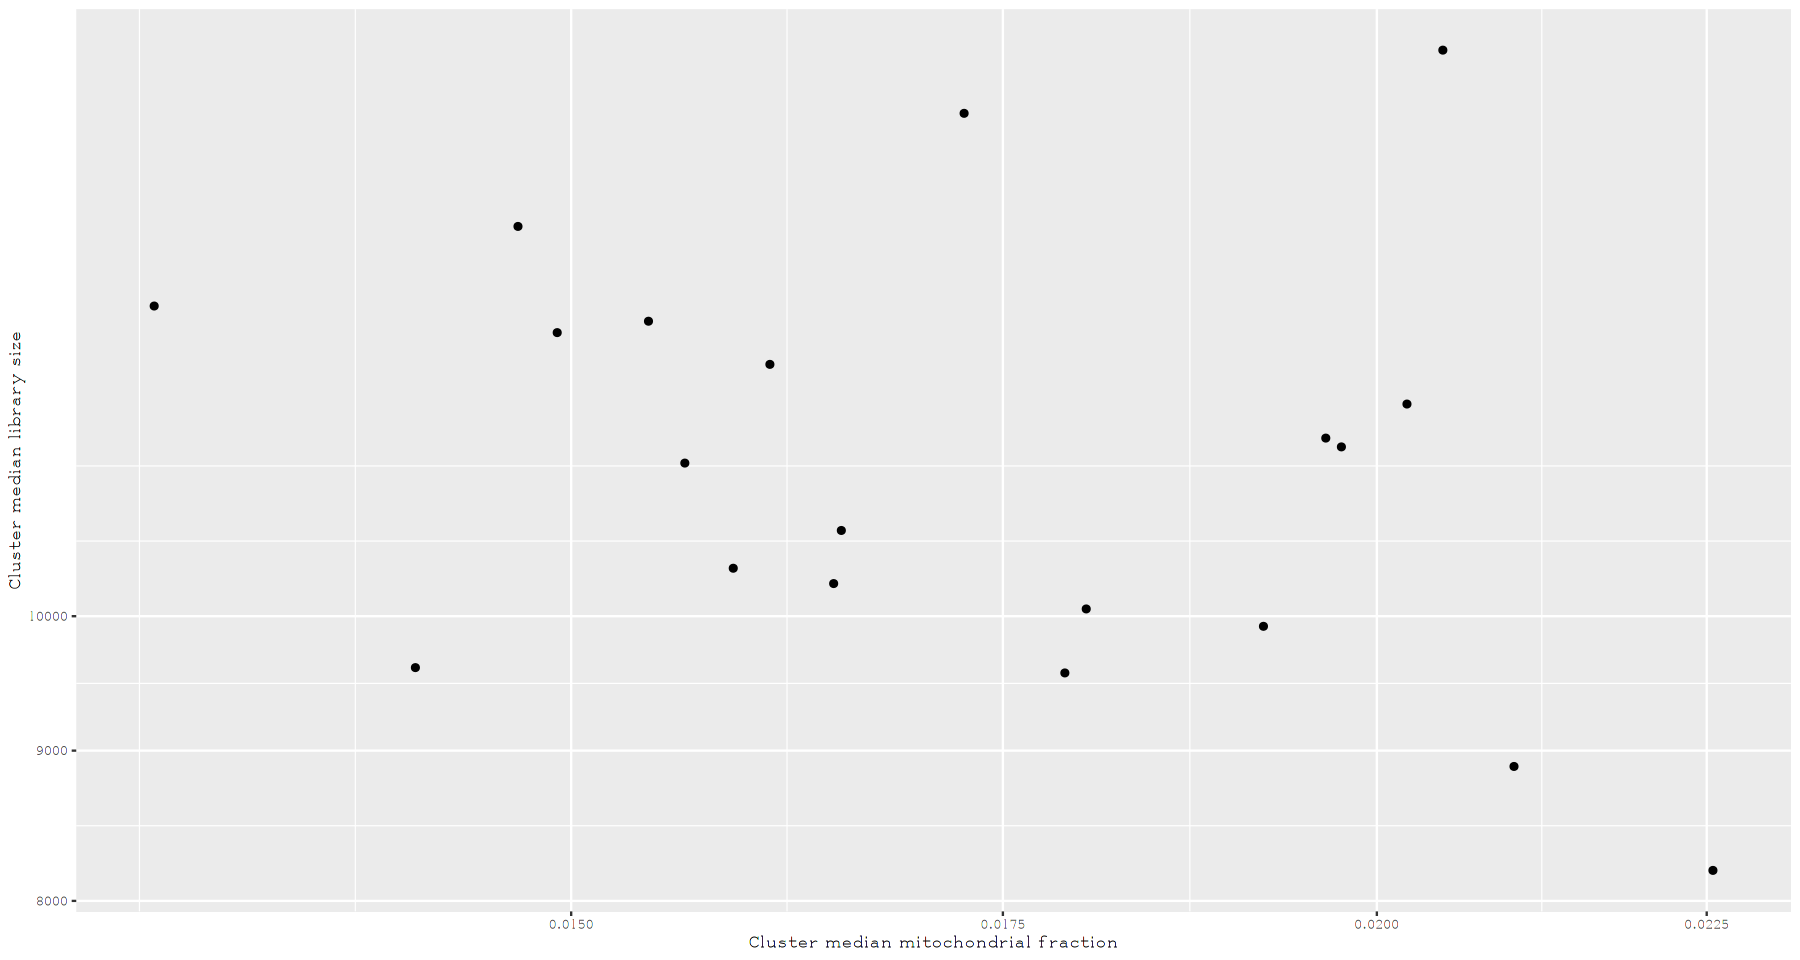

In [32]:
mouse_ensembl = useMart("ensembl")
mouse_ensembl = useDataset("mmusculus_gene_ensembl", mart = mouse_ensembl)

gene_map = getBM(attributes=c("ensembl_gene_id", "chromosome_name"), filters = "ensembl_gene_id", values = genes[,1], mart = mouse_ensembl)

mt.counts = counts(sce)[which(genes[,1] %in% gene_map$ensembl_gene_id[gene_map$chromosome_name=="MT"]), ]
mt.fraction = Matrix::colSums(mt.counts)/Matrix::colSums(counts(sce))
libsizes = Matrix::colSums(counts(sce))


meds = data.frame(mt = sapply(unique(clusts), function(x) median(mt.fraction[clusts == x])),
                  lib = sapply(unique(clusts), function(x) median(libsizes[clusts == x])),
                  cluster = unique(clusts))

meds$stripped = meds$mt < 0.005



ggplot(meds, aes (x = mt, y = lib, col = stripped)) +
  geom_point() +
  labs(x = "Cluster median mitochondrial fraction",
       y = "Cluster median library size") +
  scale_x_log10() + 
  scale_y_log10() +
  theme(legend.position = "none") +
  scale_color_manual(values = c("TRUE" = "red", "FALSE" = "black"))

In [33]:
meta$stripped = clusts %in% meds$cluster[meds$stripped]

In [34]:
kable(table(ifelse(meta$doublet, "Doublet", "Singlet"), meta$stage), caption = "Number of called doublets at each developmental timepoint.")



Table: Number of called doublets at each developmental timepoint.

|        |  E8.5|
|:-------|-----:|
|Doublet |  2395|
|Singlet | 27776|

In [35]:
kable(table(ifelse(meta$stripped, "Stripped", "Normal"), meta$stage), caption = "Number of called stripped nuclei at each developmental timepoint.")



Table: Number of called stripped nuclei at each developmental timepoint.

|       |  E8.5|
|:------|-----:|
|Normal | 30171|

In [36]:
head(meta)

,cell,barcode,stage,batch,Sample_name,batch_name,tdTom,index,sample,doub.density,doublet,stripped
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<lgl>,<lgl>
1,cell_1,AAACCCAGTTCTCTAT,E8.5,3,MLT_G9 Tom+,SLX-20795_SITTA11_HKTG2DRXY,positive,1,3,13.92512,FALSE,FALSE
2,cell_2,AAACGCTAGTGATTCC,E8.5,3,MLT_G9 Tom+,SLX-20795_SITTA11_HKTG2DRXY,positive,2,3,17.27204,FALSE,FALSE
3,cell_3,AAACGCTCATGACTCA,E8.5,3,MLT_G9 Tom+,SLX-20795_SITTA11_HKTG2DRXY,positive,3,3,10.78188,FALSE,FALSE
4,cell_4,AAAGGGCAGTCATGAA,E8.5,3,MLT_G9 Tom+,SLX-20795_SITTA11_HKTG2DRXY,positive,4,3,11.10079,FALSE,FALSE
5,cell_5,AAAGGTAAGCCTGCCA,E8.5,3,MLT_G9 Tom+,SLX-20795_SITTA11_HKTG2DRXY,positive,5,3,22.16565,TRUE,FALSE
6,cell_6,AAAGTGAAGTGTAGAT,E8.5,3,MLT_G9 Tom+,SLX-20795_SITTA11_HKTG2DRXY,positive,6,3,16.51111,FALSE,FALSE


In [37]:
nrow(meta)
nrow(meta[meta$stripped==FALSE & meta$doublet==FALSE,])

[1] 30171

[1] 27776

In [38]:
write.table(meta, file = paste0(main, '05_doublet_detection/meta.tab'), sep = "\t", quote = FALSE, row.names = FALSE, col.names = TRUE)
# save(list = ls(), file = paste0(main, '05_doublet_detection/debug.RData'))

In [39]:
sessionInfo()

R version 4.0.3 (2020-10-10)
Platform: x86_64-pc-linux-gnu (64-bit)
Running under: Manjaro Linux

Matrix products: default
BLAS:   /usr/local/lib64/R/lib/libRblas.so
LAPACK: /usr/local/lib64/R/lib/libRlapack.so

locale:
 [1] LC_CTYPE=en_GB.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_GB.UTF-8        LC_COLLATE=en_GB.UTF-8    
 [5] LC_MONETARY=en_GB.UTF-8    LC_MESSAGES=en_GB.UTF-8   
 [7] LC_PAPER=en_GB.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_GB.UTF-8 LC_IDENTIFICATION=C       

attached base packages:
[1] parallel  stats4    stats     graphics  grDevices utils     datasets 
[8] methods   base     

other attached packages:
 [1] scales_1.1.1                cowplot_1.1.1              
 [3] gridExtra_2.3               batchelor_1.6.2            
 [5] reticulate_1.18             scran_1.18.1               
 [7] knitr_1.30                  reshape2_1.4.4             
 [9] scater_1.18.3               